In [ ]:
# %%capture
# %pip install py-pde

# Install the PyBolt package directly from Github
!pip install git+https://github.com/Maxim-Laletin/PyBolt.git


In [1]:
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd
from copy import deepcopy
from scipy.integrate import solve_ivp # ODE solver
from scipy.special import kn # Bessel function
from scipy.interpolate import interp1d, CubicSpline # interpolation
from scipy.integrate import quad # integration

import cosmology 
import fBE_solver as fBE

#from pde import PDE, CartesianGrid, MemoryStorage, ScalarField, plot_kymograph, PDEBase,ScipySolver,ExplicitSolver,registered_solvers

# Defining functions

NOW WE CAN USE THE COSMOLOGY PACKAGE FOR THE QUANTITIES USED IN THIS CODE. PLEASE CHECK WHICH QUANTITIES ARE USED AND REWRITE THEM AS SOME OF THEM BELOW

In [6]:

#from Maxim for quick interpolation

# mPl=1e19#*1000
# m=1#*1000
# # log10(T/MeV) g_rho g_rho/g_s
# dof_arr = np.array([[0.00, 10.71, 1.00228],[0.50, 10.74, 1.00029],[1.00, 10.76, 1.00048],[1.25, 11.09, 1.00505],[1.60, 13.68, 1.02159],[2.00, 17.61, 1.02324],[2.15, 24.07, 1.05423],
# [2.20, 29.84, 1.07578],[2.40, 47.83, 1.06118],[2.50, 53.04, 1.04690],[3.00, 73.48, 1.01778],[4.00, 83.10, 1.00123],[4.30, 85.56, 1.00389],[4.60, 91.97, 1.00887],[5.00, 102.17, 1.00750],[5.45, 104.98, 1.00023]])

# #print(dof_arr)

# gx = dof_arr[:,0] - 3 # log10(T/GeV) points
# #gx = (10**dof_arr[:,0])/1e+3 # T points in GeV
# gy = dof_arr[:,1] # g points
# hy = dof_arr[:,1]/dof_arr[:,2] # h points

# # Constructing the cubic splines for interpolation
# gy_spline = CubicSpline(gx,gy)
# hy_spline = CubicSpline(gx,hy)

# # Functions for density and entropy dofs
# g_rho = lambda T: gy_spline(np.log10(T))
# h_s = lambda T: hy_spline(np.log10(T))


# #gx_probe = np.logspace(np.log10(gx[0]),np.log10(gx[-1]),100)
# gx_probe = np.linspace(gx[0],gx[-1],100)
# hslog = CubicSpline(dof_arr[:,0]-3,np.log10(hy))

# # Derivative of the spline
# dloghdlogT = hslog.derivative()
# # Function for gtilda
# gtilda = lambda T: (1/3)*dloghdlogT(np.log10(T))



# def Hubble(T):
#   return np.sqrt(8*(np.pi**3)*g_rho(T)/(90*mPl**2))*T**2

Hubble = cosmology.H

# def gs(T):
#   return h_s(T)

gs = cosmology.h_s

# gsPrim=hy_spline.derivative()

# def gTilde(T):
#   # sign is ok, there is cancelation between definition of gTilde and dx/dT=-m/T^2!
#   return T/h_s(T)*gsPrim(T)/3

gTilde = cosmology.gtilda

# def gTilde(T): #CORRECT
#   # sign is ok, there is cancelation between definition of gTilde and dx/dT=-m/T^2!
#   return 1/h_s(T)*gsPrim(np.log10(T))/3/np.log(10)#

# def HubbleTilde(T):
#     return Hubble(T)/(1+gTilde(T))

HubbleTilde = cosmology.H_t


In [64]:
massRatio=0.5

# The mass of the mother particle (MP)
m1 = 1.776 # (tau) GeV
# The mass of the daughter particle (DP)
m2 = 0.10565 # (muon) GeV
# The mass of the DM particle
mDM = 1e-10 # GeV

# PQ symmetry breaking scale
fa = 2e+6 # GeV
# corresponds to the freeze out

# Ratio of the two masses
mu = m2/m1

# Number of massless particle degrees of freedom
g_x = 1.0
# Number of MP dofs
g_m1 = 2.0
# Number of DP dofs
g_m2 = 2.0

# Coupling of MP-DP-x
yMDx = 1

# Decay width of MP -> DP + x
Gamma = yMDx**2*m1**3*(1-(m2/m1)**2)**3/64/np.pi/fa**2 # GeV
# Msquared for the decay

Msq= yMDx**2*m1**4*(1 - (m2/m1)**2)**2/4/fa**2 # GeV^2

# Numerical solution:

We calculate the phase-space distribution using PyBolt package

In [61]:
# Create a model of axion phase-space evolution
AxionModel = fBE.Model(m1,mDM,g_x,'b')
# m1 is the mass of the heaviest particle in the reaction

# Create an instance of the DecayToX process class
Decay = fBE.DecayToX(m1,m2,g_m1,Msq,Gamma)

# Create the grid of x and q
N_x = 500 # number of x points
N_q = 200 # number of q points
xstart = 1.0  # starting x value
xfin = 20.0 # final x value

qin = 0.0001 # smallest q value
qend = 20. # biggest q value

# Creating vectors of linearly distributed values of x and q
x_lin = np.linspace(xstart,xfin,N_x)
q_lin = np.linspace(qin,qend,N_q)

# Assigning the grid (of x and q) to the model
AxionModel.changeGrid(x_lin,q_lin)

# Add the decay collision integral to the model collision term (the only process that we consider)
AxionModel.addCollisionTerm(Decay.collisionTerm)

# Initial distribution
#f0 = np.zeros_like(q_lin)
f0 = AxionModel.equilibriumFunction(q_lin)

# fBE solver options
solver_options = {
    'method': 'BDF', # Implicit backward differentiation formula method of variable order (1-5) - because the equation is stiff
    'atol': 1e-5,   # Absolute tolerance
    'rtol': 1e-3   # Relative tolerance
}

# Solving the fBE
AxionModel.solve_fBE(f0,solver_options)

fBE solved in 0.36 seconds


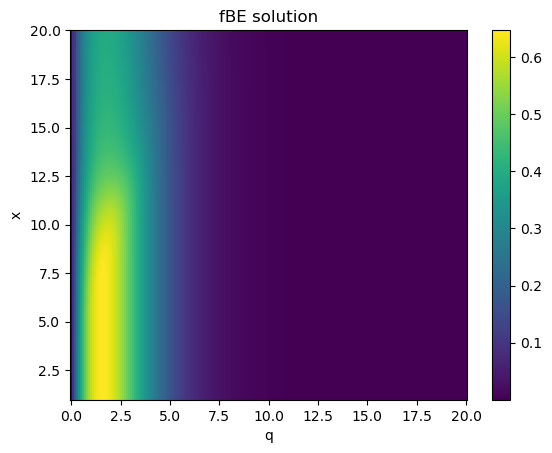

In [62]:
# Creating the kymograph plot of the solution
AxionModel.plot2D()

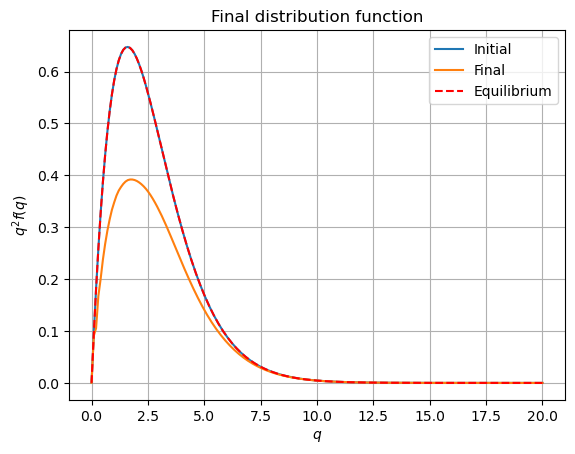

In [63]:
# Plot the initial and final solutions and the equilibrium distribution to compare
plt.figure()
plt.plot(q_lin,f0, label = 'Initial')
plt.plot(q_lin, AxionModel.getSolution()[-1,:], label = 'Final')
plt.plot(q_lin, AxionModel.equilibriumFunction(q_lin),'r--', label = 'Equilibrium')
plt.xlabel(r'$q$')
plt.ylabel(r'$q^2 f(q)$')
plt.title("Final distribution function")
plt.legend(loc="upper right")
plt.grid()
plt.show()

# PINN


In [ ]:
def _construct_FC_layers(hidden, input_dim, output_dim, activations):
    """Constructs the layer structure for a fully connected neural network.
      returns list of layers
    """
    layers = []
    layers.append(torch.nn.Linear(input_dim, hidden[0]))
    layers.append(activations)
    for i in range(len(hidden)-1):
        layers.append(torch.nn.Linear(hidden[i], hidden[i+1]))
        layers.append(activations)
    layers.append(torch.nn.Linear(hidden[-1], output_dim))
    return layers

def normalize(x, x_min, x_max):
    """scales [x_min, x_max] to [-1, 1] range"""
    return 2.*(x-x_min)/(x_max-x_min) -1

class FCN(torch.nn.Module):
    """A simple fully connected neural network.

    Parameters
    ----------
    input_dim : int
        The space of the points the can be put into this model.
    output_dim : int
        The space of the points returned by this model.
    hidden : list or tuple
        The number and size of the hidden layers of the neural network.
        The lenght of the list/tuple will be equal to the number
        of hidden layers, while the i-th entry will determine the number
        of neurons of each layer.
        E.g hidden = (10, 5) -> 2 layers, with 10 and 5 neurons.
    activations : torch.nn, optional
        The activation functions of this network. Deafult is nn.Tanh().
    """
    def __init__(self,
                 input_dim,
                 output_dim,
                 hidden=(20,20,20),
                 activations=torch.nn.Tanh(), # check other activation functions, simgoid might be better as it is more 0 centered and Y~0??
                 normalize=False,
                 x_max = None,
                 x_min = None
                ):
        super().__init__()

        self.normalize = normalize
        if self.normalize:
            self.register_buffer('x_max', torch.tensor(x_max).float())
            self.register_buffer('x_min', torch.tensor(x_min).float())
        layers = _construct_FC_layers(hidden=hidden, input_dim=input_dim,
                                      output_dim=output_dim,
                                      activations=activations)

        self.sequential = torch.nn.Sequential(*layers)

    def forward(self, *x):
        x = torch.cat(x, dim=-1) # concatenate along last dimension
        if self.normalize:
            x = normalize(x, self.x_min, self.x_max)
        return self.sequential(x)

In [ ]:
def grad(model_out, *derivative_variable):
    '''Computes the gradient of a network with respect to the given variable.
    Parameters
    ----------
    model_out : torch.tensor
        The (scalar) output tensor of the neural network
    derivative_variable : torch.tensor
        The input tensor of the variables in which respect the derivatives have to
        be computed
    Returns
    ----------
    torch.tensor
        A Tensor, where every row contains the values of the the first
        derivatives (gradient) w.r.t the row of the input variable.
    '''
    grad = []
    for vari in derivative_variable:
        new_grad = torch.autograd.grad(model_out.sum(), vari,
                                       create_graph=True, allow_unused=True)[0]
        grad.append(new_grad)
    return torch.column_stack(grad)

In [ ]:
def uniform_sampler(batch_size, x_min, x_max):
    """
    Samples uniformly from the given ranges for each dimension.

    Parameters:
    - batch_size (int): Number of samples to generate.
    - x_min (list or torch.Tensor): Lower bounds for each dimension.
    - x_max (list or torch.Tensor): Upper bounds for each dimension.

    Returns:
    - x (torch.Tensor): Tensor of shape (batch_size, len(x_min)) containing the samples.
    """
    x_min = torch.tensor(x_min).float()
    x_max = torch.tensor(x_max).float()

    # Generate uniform samples in the range [0, 1]
    rand_samples = torch.rand(batch_size, len(x_min))

    # Scale and shift the samples to the desired range
    samples = x_min + (x_max - x_min) * rand_samples

    return samples

In [ ]:
def FullBoltzmannEquation_residual_torch(f,x,q):
  massRatio=0.5
  m1=1
  m2=0.5
  fa=4e8
  g_x=1
  yMDx=1
  Gamma = yMDx**2*m1**3*(1-(m2/m1)**2)**3/64/np.pi # GeV
  Msq= yMDx**2*m1**4*(1 - (m2/m1)**2)**2/4/fa**2 # GeV^2
  Elim1 = torch.max(torch.stack([x*(torch.ones(q.shape).to(device)), x*massRatio+q, x**2*(1 + 4*q**2/(x**2*(1-massRatio**2)) - (1-massRatio**2) )/4/q],dim=1),1)
  Elim2 = torch.max(torch.stack([x-q, x*massRatio*(torch.ones(q.shape).to(device)), x**2/4/q],dim=1),1)
  gradient=grad(f(x,q),x,q)
  dY_dq = gradient[:,1]
  dY_dt=gradient[:,0]
  feq= q**2/(torch.exp(q) - 1.0)
  #(gTilde(m1/t)*(dY_dx*Momentum_x[:,0] - 2*state) + q2CollTerm/HubbleTilde(m1/t))/t
  q2CollTerm = (((2*x*Msq/16/np.pi/g_x/q**2)*(torch.log((1+torch.exp(-Elim1.values))/(1+torch.exp(-Elim2.values))))))*(f(x,q) - feq)
  gTildeInternal=torch.from_numpy(gTilde(m1/x.cpu().detach().numpy())).to(device)
  HubbleTildeInternal=torch.from_numpy(HubbleTilde(m1/x.cpu().detach().numpy())).to(device)
  return dY_dt-(gTildeInternal*(dY_dq*q - 2*f(x,q))+q2CollTerm/HubbleTildeInternal)/x

In [ ]:
# qLin = torch.reshape(torch.linspace(0, 12, steps=100).requires_grad_(True),(100,1))
# xLin = x0*torch.ones_like(qLin)



# x_grid,q_grid=torch.meshgrid(torch.squeeze(xLin), torch.squeeze(qLin),indexing="ij")


def InitialCondition(q):
  feq= q**2/(torch.exp(q) - 1.0)
  return feq
# print(torch.stack(((torch.ones_like(qLin)*x0, qLin)), dim=1))
# xq_BC=torch.reshape(torch.stack(((x_grid, q_grid)), dim=-1),(100,2))
# xq_BC=torch.reshape(torch.stack(((xLin, qLin)), dim=-1),(100,2))

def InitialCondition_residual(f,x,q):
  feq= q**2/(torch.exp(q) - 1.0)
  return f(x,q)-feq




In [ ]:
device= 'cuda' if torch.cuda.is_available() else 'cpu'

data_loss_function = torch.nn.functional.mse_loss

def physics_loss_function(residual):
    return torch.mean(residual**2)


# def physics_loss_function(residual):
#     return torch.sum(residual**2)




# Learning

0 {'boundary': 0.08884474635124207, 'physics': 0.016452899017248408, 'weighted_sum': 0.10529764536849047, 'last LR': 0.01, 'MSE': 0.05297189628448501}
250 {'boundary': 0.03503164276480675, 'physics': 0.000446619558671859, 'weighted_sum': 0.03547826232347861, 'last LR': 0.01, 'MSE': 0.06162148739547723}
500 {'boundary': 0.00511160446330905, 'physics': 0.0005138334946188309, 'weighted_sum': 0.0056256721164053775, 'last LR': 0.01, 'MSE': 0.10826796121932825}


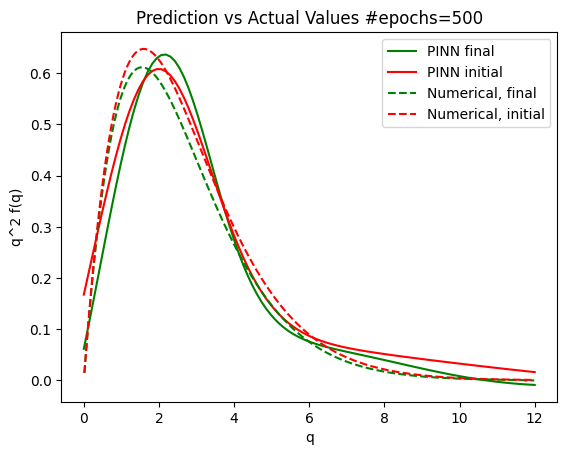

750 {'boundary': 0.00015032244846224785, 'physics': 4.654420294950279e-05, 'weighted_sum': 0.00019686665141175063, 'last LR': 0.01, 'MSE': 0.07498224790503269}
1000 {'boundary': 0.005567797925323248, 'physics': 0.0004892123492364109, 'weighted_sum': 0.006057010274559659, 'last LR': 0.01, 'MSE': 0.09446870008718139}


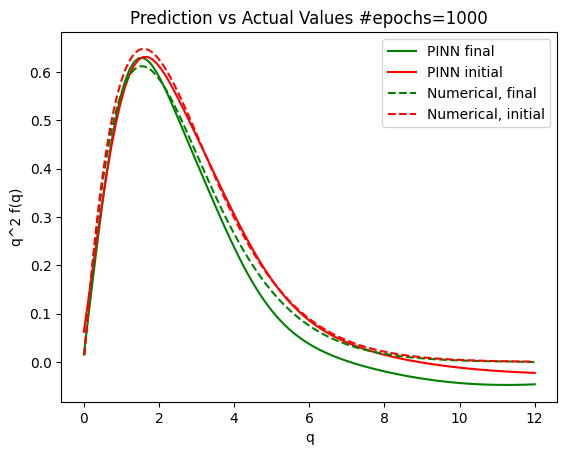

1250 {'boundary': 0.0003353580250404775, 'physics': 0.00035007938829437776, 'weighted_sum': 0.0006854374133348553, 'last LR': 0.01, 'MSE': 0.08732491542691895}
1500 {'boundary': 0.00018018443370237947, 'physics': 0.0003026817540625202, 'weighted_sum': 0.00048286618776489964, 'last LR': 0.01, 'MSE': 0.10097707750017454}


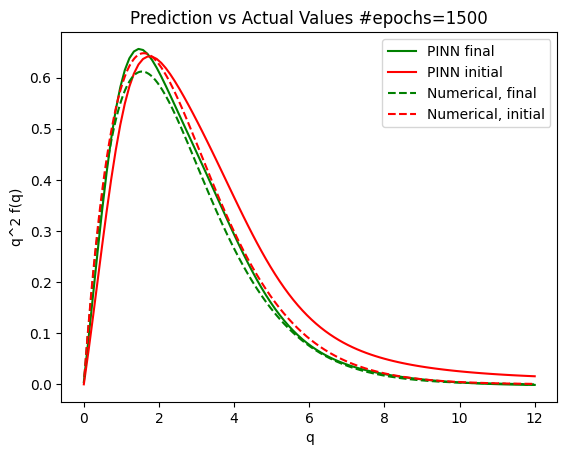

1750 {'boundary': 0.0002802251256071031, 'physics': 0.0003498188671576137, 'weighted_sum': 0.0006334839477451389, 'last LR': 0.01, 'MSE': 0.08576283657113262}
2000 {'boundary': 0.0004124560218770057, 'physics': 0.00028414167264201274, 'weighted_sum': 0.0006965976945190184, 'last LR': 0.01, 'MSE': 0.10013454062043005}


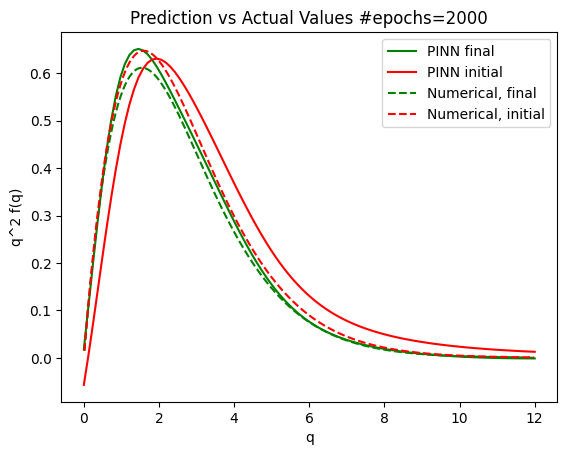

2250 {'boundary': 0.000380387413315475, 'physics': 0.0004340648327999757, 'weighted_sum': 0.0008149133498679645, 'last LR': 0.01, 'MSE': 0.10903860884220266}
2500 {'boundary': 0.00015890321810729802, 'physics': 9.511895597105708e-05, 'weighted_sum': 0.0002540221740783551, 'last LR': 0.01, 'MSE': 0.09051449791102019}


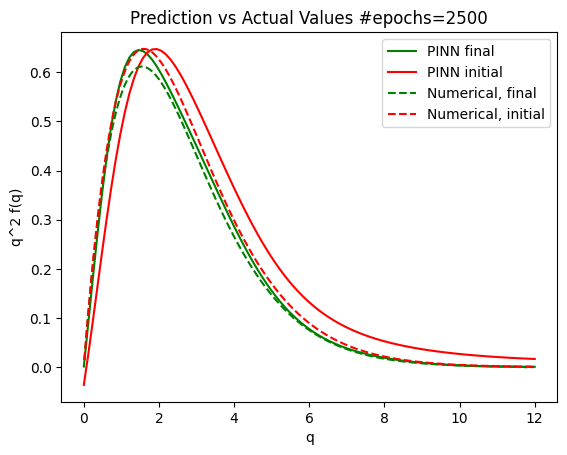

2750 {'boundary': 0.00011871603783220053, 'physics': 0.0002723911526298881, 'weighted_sum': 0.0003911219005663344, 'last LR': 0.01, 'MSE': 0.0891968953402282}
3000 {'boundary': 0.001746851485222578, 'physics': 0.0005271581916953261, 'weighted_sum': 0.002274009676917904, 'last LR': 0.01, 'MSE': 0.0940352016336869}


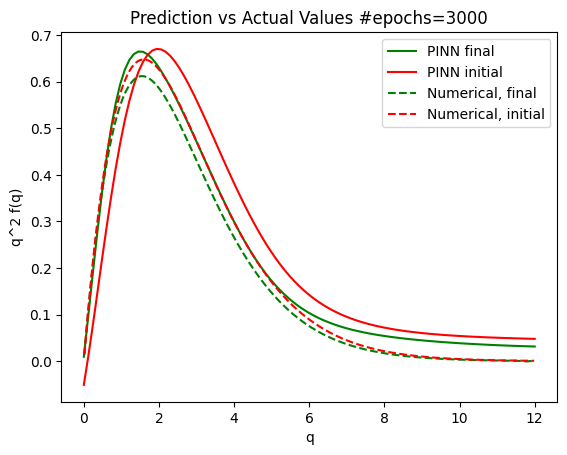

3250 {'boundary': 8.095712109934539e-05, 'physics': 0.0005772323432768121, 'weighted_sum': 0.0006581894643761575, 'last LR': 0.01, 'MSE': 0.0939117288392788}
3500 {'boundary': 0.00014041439862921834, 'physics': 0.00025439594293136074, 'weighted_sum': 0.0003948103415605791, 'last LR': 0.01, 'MSE': 0.08004450538366506}


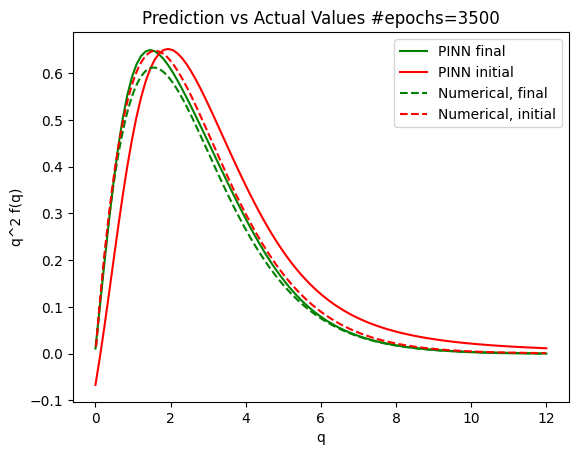

3750 {'boundary': 0.0001872955763246864, 'physics': 0.00046805410915905433, 'weighted_sum': 0.0006555573745958712, 'last LR': 0.01, 'MSE': 0.07382975427502822}
4000 {'boundary': 0.00017548676987644285, 'physics': 0.0005115515615634459, 'weighted_sum': 0.0006870383314398887, 'last LR': 0.01, 'MSE': 0.0945256916028411}


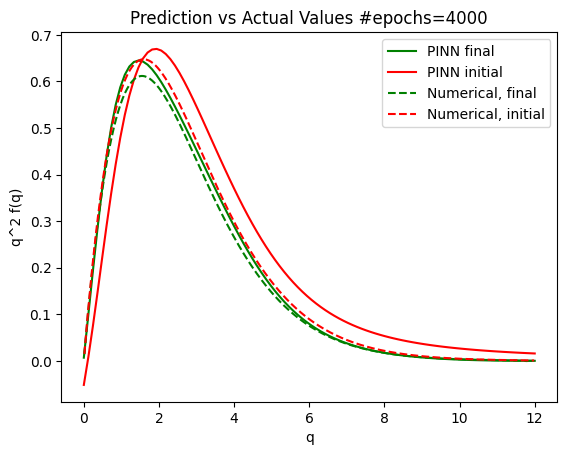

In [ ]:



model_f=FCN(2,1,hidden=(32,32), normalize=True, x_min=[x0,q0], x_max=[xf, qf],activations=torch.nn.Tanh())

batch_size_collocation=20
physics_weight = 40.
bc_weight=1
num_epochs_adam = 4001
collocation_number_plot=100
parameters = [*model_f.parameters()]

optimizer = torch.optim.Adam(parameters, lr=1e-2,weight_decay=1e-5)
# optimizer = torch.optim.SGD(parameters, lr=1e-2, momentum=0.9)






model_f.train().to(device)

history =[]


historyTotalLoss = np.array([])
for epoch in range(num_epochs_adam):

    optimizer.zero_grad()  # Clear gradients before next loss is computed
    # randomly sample points, don't use always the same
    x_sample = uniform_sampler(batch_size_collocation, [x0], [xf])
    q_sample = uniform_sampler(batch_size_collocation, [q0], [qf])#.to(device)
    x_gridS,q_gridS=torch.meshgrid(torch.squeeze(x_sample), torch.squeeze(q_sample),indexing="ij")
    xq_grid=torch.reshape(torch.stack(((x_gridS, q_gridS)), dim=-1),(batch_size_collocation**2,2))
    xq_grid.requires_grad=True
    x_grid=torch.reshape(xq_grid[:,0],(batch_size_collocation**2,1)).to(device)
    q_grid=torch.reshape(xq_grid[:,1],(batch_size_collocation**2,1)).to(device)



    #boundary conditions at q=0,12
    bc_loss1=physics_loss_function(model_f(x_grid,torch.zeros_like(q_grid)))
    bc_loss2=physics_loss_function(model_f(x_grid,qf*torch.ones_like(q_grid))-qf**2/(np.exp(qf)-1)*torch.ones_like(model_f(x_grid,qf*torch.ones_like(q_grid)).to(device))) #it approaches value of feq(q=12), but I can also set feq(q=12, x=xf)?
    bc_loss=bc_loss1+bc_loss2
    #initial conidtion
    ini_residual=InitialCondition_residual(model_f,x_grid,q_grid)
    ini_loss=physics_loss_function(ini_residual)
    BC_loss=bc_loss+ini_loss



    # PDE
    physics_residual =FullBoltzmannEquation_residual_torch(model_f, x_grid,q_grid)
    physics_loss = physics_loss_function(physics_residual)
    physics_loss_weighted = physics_weight * physics_loss

    #positivity of distribution
    loss_positivity=10*physics_loss_function(torch.abs(model_f(x_grid,q_grid))-model_f(x_grid,q_grid))

    loss =  physics_loss_weighted+BC_loss+loss_positivity
    loss.backward()


    #displaying current value of learning rate
    current_lr = optimizer.param_groups[0]["lr"]

    #calculate the MSE wrt numerical results
    MSE_numerical=np.mean((NumericalFinalDistribution-np.reshape(model_f(xf*torch.ones_like(x_grid), q_grid).cpu().detach().numpy(),400))**2)

    losses = {
        'boundary': BC_loss.item(),
        'physics': physics_loss_weighted.item(),
        'weighted_sum': loss.item(),
        'last LR': current_lr,
        'MSE': MSE_numerical
        }

    historyTotalLoss=np.append(historyTotalLoss,loss.item())
    mean_of_last_losses=np.mean(historyTotalLoss[-100:])
    # scheduler.step(mean_of_last_losses)




    optimizer.step()  # Update weights


    history.append(losses)
    if epoch % 250 == 0:
        print(epoch, losses)
    if epoch % 500 == 0 and epoch != 0:
        q_values=torch.reshape(torch.linspace(q0, qf, steps=collocation_number_plot),(collocation_number_plot,1))
        x_values_fin = torch.reshape(torch.ones_like(q_values)*xf,(collocation_number_plot,1)).to(device)
        x_values_ini = torch.reshape(torch.ones_like(q_values)*1,(collocation_number_plot,1)).to(device)
        q_values=q_values.to(device)
        x_values_ini=x_values_ini.to(device)

        # Get predictions for all y_values
        NN_final = model_f(x_values_fin, q_values)
        NN_initial = model_f(x_values_ini, q_values)

        X_plot=q_values.cpu().detach().numpy()
        NN_final_plot=NN_final.cpu().detach().numpy()
        NN_initial_plot=NN_initial.cpu().detach().numpy()
        # Plot actual values (y_values) vs predictions
        plt.plot(X_plot, NN_final_plot,label='PINN final',color='g')
        plt.plot(X_plot, NN_initial_plot,label='PINN initial',color='r')
        plt.plot(grid.cell_coords,storage.data[-1],'g--',label='Numerical, final')
        plt.plot(grid.cell_coords,state_eq.data, 'r--', label = 'Numerical, initial')

        # Add labels and title
        plt.xlabel("q")
        plt.ylabel("q^2 f(q)")
        plt.title(f"Prediction vs Actual Values #epochs={epoch}")
        plt.legend()
        plt.show()


history = pd.DataFrame(history)
